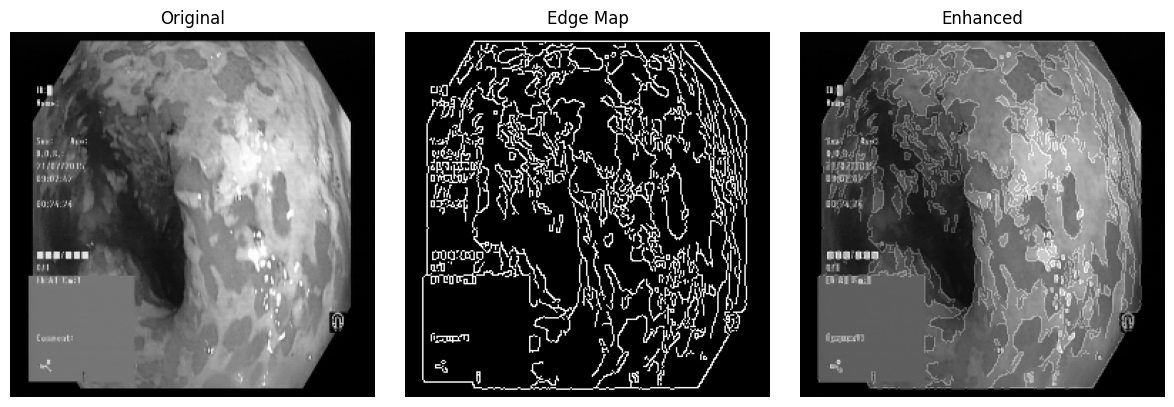

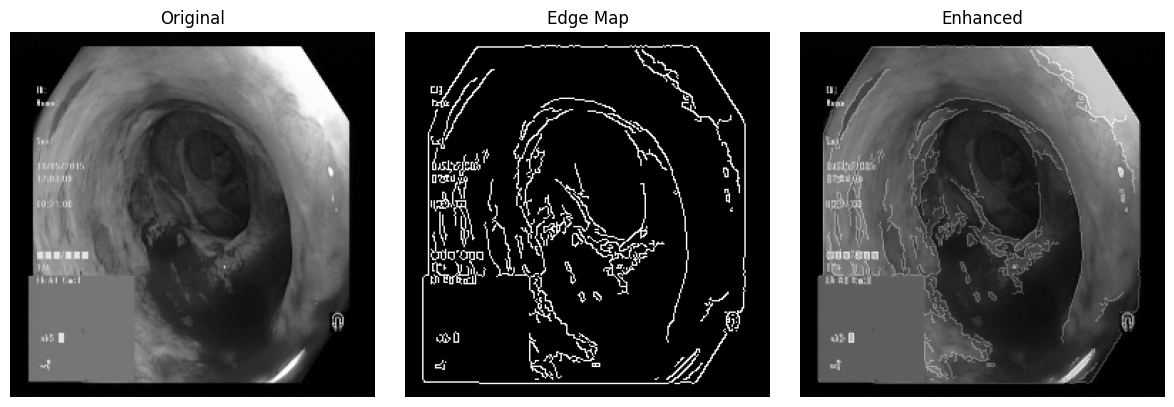

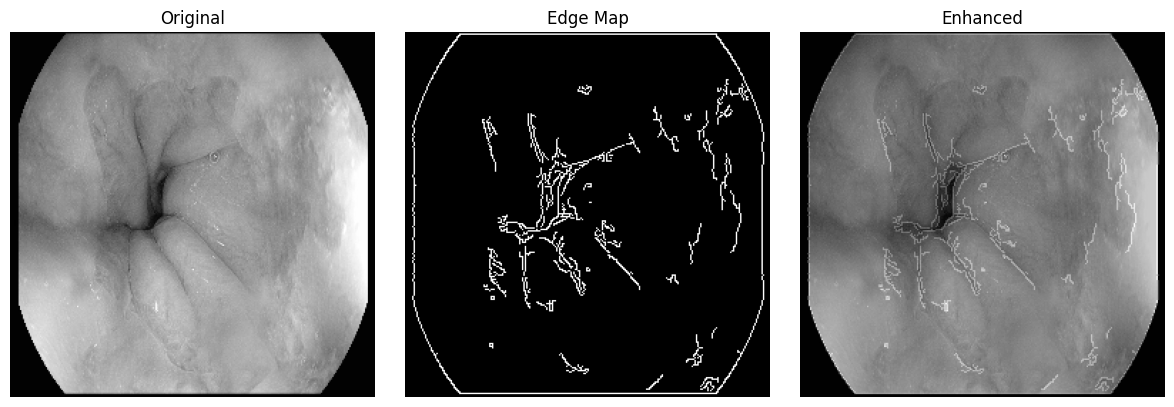

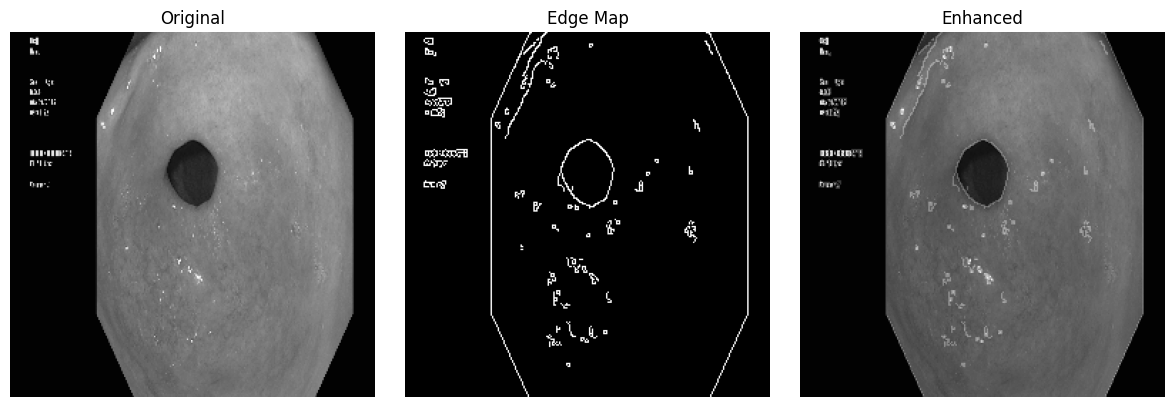

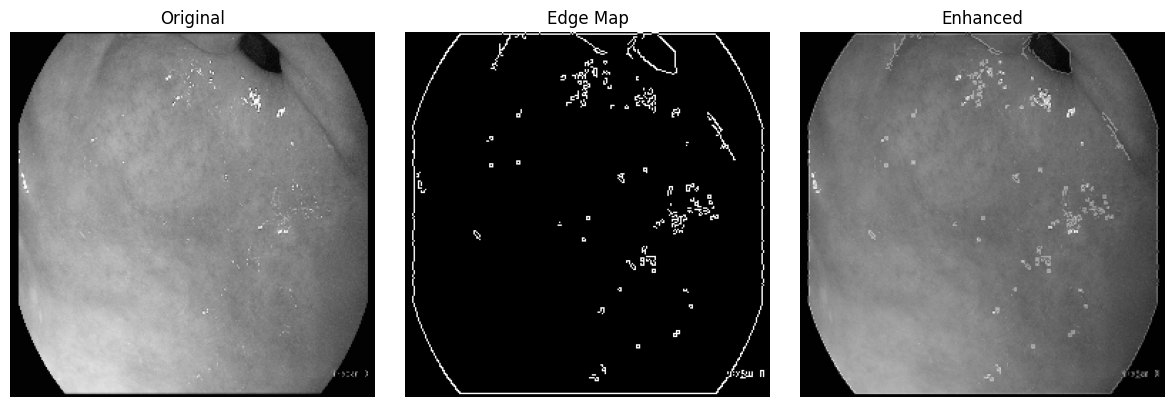

In [28]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

def load_and_resize(image_path, size=(256, 256)):
    """Load an image, convert to grayscale, and resize it."""
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Image not found at {image_path}")
    img = cv2.resize(img, size)
    return img

def extract_edges(img, low_threshold=50, high_threshold=150):
    """Extract edges using Canny edge detection."""
    edges = cv2.Canny(img, low_threshold, high_threshold)
    return edges

def blend_images(original, edges, alpha=0.8, beta=0.2):
    """
    Blend the original image with the edge map.
    The parameters alpha and beta determine the blending weights.
    """
    # Since both images are in grayscale and same size, we can blend directly.
    blended = cv2.addWeighted(original, alpha, edges, beta, 0)
    return blended

def process_image(image_path, output_dir, size=(256, 256)):
    """
    Process a single image: load, resize, extract edges, blend,
    and save the original, edge map, and enhanced image.
    """
    # Load and resize the image
    original = load_and_resize(image_path, size)
    
    # Extract edges
    edges = extract_edges(original)
    
    # Blend original and edge map
    enhanced = blend_images(original, edges)
    
    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)
    
    # Define filenames for saving
    base_name = os.path.basename(image_path)
    orig_filename = os.path.join(output_dir, f"original_{base_name}")
    edges_filename = os.path.join(output_dir, f"edges_{base_name}")
    enhanced_filename = os.path.join(output_dir, f"enhanced_{base_name}")
    
    # Save the images
    cv2.imwrite(orig_filename, original)
    cv2.imwrite(edges_filename, edges)
    cv2.imwrite(enhanced_filename, enhanced)
    
    return original, edges, enhanced

def visualize_results(original, edges, enhanced):
    """Display original, edge map, and enhanced image side-by-side."""
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(edges, cmap='gray')
    plt.title("Edge Map")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(enhanced, cmap='gray')
    plt.title("Enhanced")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

# Example usage:
if __name__ == "__main__":
    # Define input folder containing images and output folder for processed data
    input_folder = "/kaggle/input/endoscopygoodimages/Original"
    output_folder = "/kaggle/working/processed_data"
    
    # Get a list of images (you can adjust the extension filter as needed)
    image_paths = [os.path.join(input_folder, f) for f in os.listdir(input_folder) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    
    # Process a few sample images (let's do 5 samples for visualization)
    samples_to_show = 5
    for i, img_path in enumerate(image_paths[:samples_to_show]):
        orig, edge_map, enhanced = process_image(img_path, output_folder)
        visualize_results(orig, edge_map, enhanced)


Epoch [1/1000], Loss: 0.4416
Epoch [2/1000], Loss: 0.4372
Epoch [3/1000], Loss: 0.4327
Epoch [4/1000], Loss: 0.4273
Epoch [5/1000], Loss: 0.4223
Epoch [6/1000], Loss: 0.4218
Epoch [7/1000], Loss: 0.4206
Epoch [8/1000], Loss: 0.4166
Epoch [9/1000], Loss: 0.4128
Epoch [10/1000], Loss: 0.4098
Epoch [11/1000], Loss: 0.4069
Epoch [12/1000], Loss: 0.4045
Epoch [13/1000], Loss: 0.4016
Epoch [14/1000], Loss: 0.3996
Epoch [15/1000], Loss: 0.3979
Epoch [16/1000], Loss: 0.3960
Epoch [17/1000], Loss: 0.3941
Epoch [18/1000], Loss: 0.3914
Epoch [19/1000], Loss: 0.3899
Epoch [20/1000], Loss: 0.3874
Epoch [21/1000], Loss: 0.3837
Epoch [22/1000], Loss: 0.3808
Epoch [23/1000], Loss: 0.3765
Epoch [24/1000], Loss: 0.3716
Epoch [25/1000], Loss: 0.3653
Epoch [26/1000], Loss: 0.3564
Epoch [27/1000], Loss: 0.3460
Epoch [28/1000], Loss: 0.3325
Epoch [29/1000], Loss: 0.3214
Epoch [30/1000], Loss: 0.3105
Epoch [31/1000], Loss: 0.3105
Epoch [32/1000], Loss: 0.3107
Epoch [33/1000], Loss: 0.3072
Epoch [34/1000], Lo

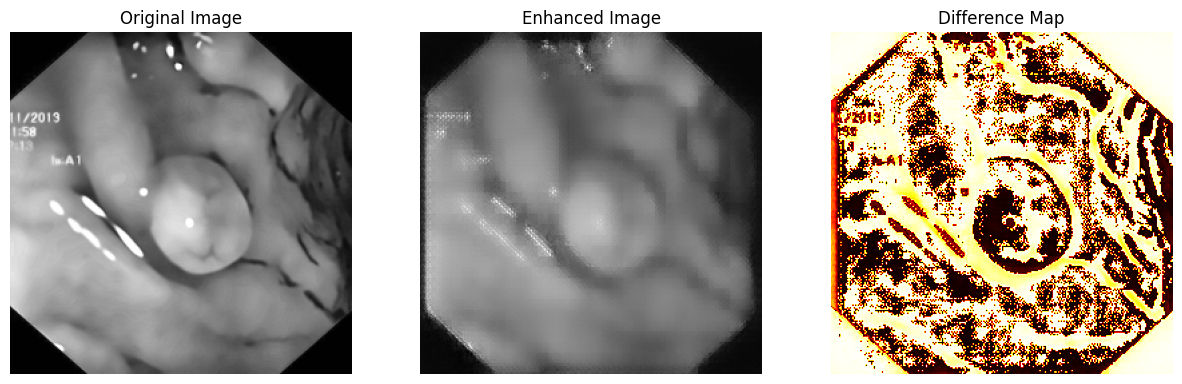

PSNR: 23.08 dB, SSIM: 0.7689


In [29]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchvision.models import vgg16
from skimage.metrics import peak_signal_noise_ratio as psnr_metric, structural_similarity as ssim_metric

# -----------------------------
# Part 2.1: Custom Dataset Loader
# -----------------------------
class ProcessedImagesDataset(Dataset):
    """
    Dataset that loads preprocessed (edge-enhanced) images.
    Here, we assume the preprocessed images are stored in 'processed_data'
    and are grayscale images.
    """
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.image_files = [os.path.join(image_dir, f) for f in os.listdir(image_dir) 
                            if f.lower().endswith(('.jpg', '.png', '.jpeg')) and 'enhanced' in f]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        # Load in grayscale
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"Failed to load image at {img_path}")
        # Normalize and convert to tensor
        img = cv2.resize(img, (256, 256))
        img = img / 255.0
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        # For an autoencoder, input and target are the same
        return img, img

# -----------------------------
# Part 2.2: UNet Autoencoder Model
# -----------------------------
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        # Encoder: downsampling
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True)
        )
        # Decoder: upsampling
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2), nn.ReLU(inplace=True)
        )
        # Final convolution to bring back to 1 channel output
        self.final = nn.Conv2d(64, 1, kernel_size=1)
    
    def forward(self, x):
        enc = self.encoder(x)
        bottleneck = self.bottleneck(enc)
        dec = self.decoder(bottleneck)
        out = self.final(dec)
        return out

# -----------------------------
# Part 2.3: Perceptual Loss using VGG (Optional but recommended)
# -----------------------------
class PerceptualLoss(nn.Module):
    def __init__(self):
        super(PerceptualLoss, self).__init__()
        # Use the first few layers of VGG16 to capture perceptual features
        vgg = vgg16(pretrained=True).features[:8]
        self.vgg = vgg.eval()
        for param in self.vgg.parameters():
            param.requires_grad = False
    
    def forward(self, pred, target):
        # Since VGG expects 3 channels, replicate the grayscale image three times
        pred_3c = pred.repeat(1, 3, 1, 1)
        target_3c = target.repeat(1, 3, 1, 1)
        pred_features = self.vgg(pred_3c)
        target_features = self.vgg(target_3c)
        loss = torch.mean((pred_features - target_features) ** 2)
        return loss

# -----------------------------
# Part 2.4: Training Loop Setup
# -----------------------------
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize dataset and dataloader
dataset_dir = "processed_data"  # Folder where processed enhanced images are saved
dataset = ProcessedImagesDataset(dataset_dir)
data_loader = DataLoader(dataset, batch_size=4, shuffle=True)

# Initialize model, loss functions, and optimizer
model = UNet().to(device)
criterion_mse = nn.MSELoss()
criterion_perceptual = PerceptualLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Number of epochs for training (adjust as needed)
num_epochs = 1000

# Training loop
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for inputs, targets in data_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss_mse = criterion_mse(outputs, targets)
        loss_perc = criterion_perceptual(outputs, targets)
        # Combine losses; adjust the weight of perceptual loss as needed
        loss = loss_mse + 0.1 * loss_perc
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * inputs.size(0)
    
    avg_loss = epoch_loss / len(dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

# Save the trained model
torch.save(model.state_dict(), "enhancement_model.pth")
print("Model saved successfully!")

# -----------------------------
# Part 2.5: Evaluation on Test Images
# -----------------------------
def evaluate_model(model, image_path):
    model.eval()
    # Load test image (assuming grayscale and resized to 256x256)
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (256, 256))
    img_norm = img / 255.0
    img_tensor = torch.tensor(img_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output_tensor = model(img_tensor)
    output_img = output_tensor.squeeze().cpu().numpy() * 255.0
    output_img = np.clip(output_img, 0, 255).astype(np.uint8)
    
    # Compute PSNR and SSIM
    psnr_val = psnr_metric(img, output_img, data_range=255)
    ssim_val = ssim_metric(img, output_img, data_range=255)
    
    # Visualize the results
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(img, cmap='gray'); axs[0].set_title("Original Image"); axs[0].axis('off')
    axs[1].imshow(output_img, cmap='gray'); axs[1].set_title("Enhanced Image"); axs[1].axis('off')
    axs[2].imshow(np.abs(img - output_img), cmap='hot'); axs[2].set_title("Difference Map"); axs[2].axis('off')
    plt.show()
    
    return psnr_val, ssim_val

# Example evaluation
test_image_path = "/kaggle/input/preprocessed2/PreProcessed1/processed_image_10.jpg"  # Replace with an actual test image path
psnr_score, ssim_score = evaluate_model(model, test_image_path)
print(f"PSNR: {psnr_score:.2f} dB, SSIM: {ssim_score:.4f}")


SRCNN Epoch [1/20], Loss: 0.1199
SRCNN Epoch [2/20], Loss: 0.0785
SRCNN Epoch [3/20], Loss: 0.0464
SRCNN Epoch [4/20], Loss: 0.0218
SRCNN Epoch [5/20], Loss: 0.0086
SRCNN Epoch [6/20], Loss: 0.0064
SRCNN Epoch [7/20], Loss: 0.0108
SRCNN Epoch [8/20], Loss: 0.0141
SRCNN Epoch [9/20], Loss: 0.0135
SRCNN Epoch [10/20], Loss: 0.0105
SRCNN Epoch [11/20], Loss: 0.0074
SRCNN Epoch [12/20], Loss: 0.0057
SRCNN Epoch [13/20], Loss: 0.0054
SRCNN Epoch [14/20], Loss: 0.0059
SRCNN Epoch [15/20], Loss: 0.0065
SRCNN Epoch [16/20], Loss: 0.0066
SRCNN Epoch [17/20], Loss: 0.0062
SRCNN Epoch [18/20], Loss: 0.0055
SRCNN Epoch [19/20], Loss: 0.0049
SRCNN Epoch [20/20], Loss: 0.0046
SRCNN model saved successfully!


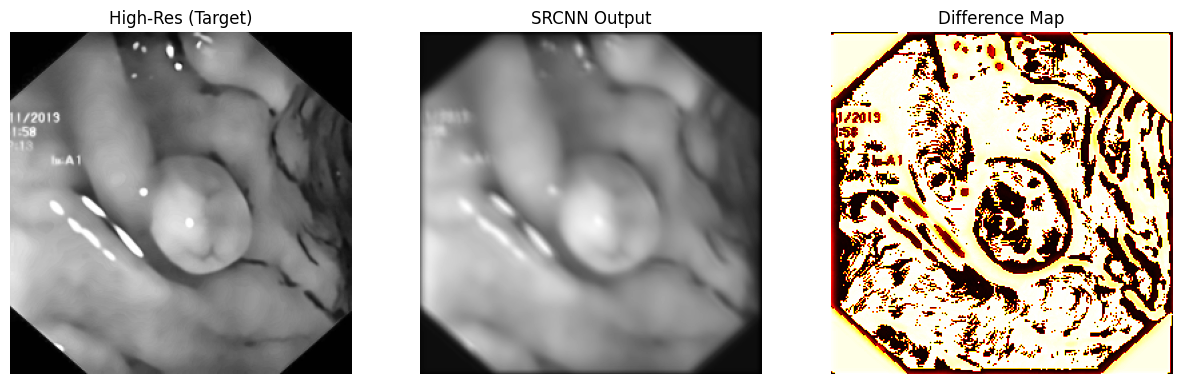

SRCNN - PSNR: 26.40 dB, SSIM: 0.8508


In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

# -----------------------------
# Dataset for Super-Resolution
# -----------------------------
class SuperResDataset(Dataset):
    """
    Dataset for Super Resolution:
    - High-res images (target) are taken from the preprocessed images.
    - Low-res inputs are generated on the fly by downscaling and upscaling.
    """
    def __init__(self, image_dir, scale_factor=2, transform=None):
        self.image_dir = image_dir
        self.image_files = [os.path.join(image_dir, f) for f in os.listdir(image_dir) 
                            if f.lower().endswith(('.jpg', '.png', '.jpeg')) and 'enhanced' in f]
        self.scale_factor = scale_factor
        self.transform = transform
        
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        # Load high-res image in grayscale
        img_path = self.image_files[idx]
        hr_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        hr_img = cv2.resize(hr_img, (256, 256))
        
        # Normalize and convert to float32
        hr_img = hr_img.astype(np.float32) / 255.0
        
        # Create low-resolution input: downscale then upscale using bicubic interpolation
        lr_size = (256 // self.scale_factor, 256 // self.scale_factor)
        lr_img = cv2.resize(hr_img, lr_size, interpolation=cv2.INTER_CUBIC)
        lr_img = cv2.resize(lr_img, (256, 256), interpolation=cv2.INTER_CUBIC)
        
        # Convert to tensor and add channel dimension
        hr_tensor = torch.tensor(hr_img, dtype=torch.float32).unsqueeze(0)
        lr_tensor = torch.tensor(lr_img, dtype=torch.float32).unsqueeze(0)
        
        return lr_tensor, hr_tensor

# -----------------------------
# SRCNN Model Definition
# -----------------------------
class SRCNN(nn.Module):
    def __init__(self):
        super(SRCNN, self).__init__()
        self.layer1 = nn.Conv2d(1, 64, kernel_size=9, padding=4)
        self.layer2 = nn.Conv2d(64, 32, kernel_size=5, padding=2)
        self.layer3 = nn.Conv2d(32, 1, kernel_size=5, padding=2)
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

# -----------------------------
# Training SRCNN
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset_dir = "/kaggle/working/processed_data"  # Directory where processed enhanced images are saved
sr_dataset = SuperResDataset(dataset_dir, scale_factor=2)
sr_loader = DataLoader(sr_dataset, batch_size=4, shuffle=True)

srcnn = SRCNN().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(srcnn.parameters(), lr=1e-4)

num_epochs = 20
for epoch in range(num_epochs):
    srcnn.train()
    epoch_loss = 0
    for lr_imgs, hr_imgs in sr_loader:
        lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
        optimizer.zero_grad()
        outputs = srcnn(lr_imgs)
        loss = criterion(outputs, hr_imgs)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * lr_imgs.size(0)
    avg_loss = epoch_loss / len(sr_dataset)
    print(f"SRCNN Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

# Save SRCNN model
torch.save(srcnn.state_dict(), "srcnn_model.pth")
print("SRCNN model saved successfully!")

# -----------------------------
# Evaluate SRCNN on a Test Image
# -----------------------------
def evaluate_srcnn(model, image_path):
    model.eval()
    # Load and preprocess test image
    hr_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    hr_img = cv2.resize(hr_img, (256, 256))
    hr_img_norm = hr_img.astype(np.float32) / 255.0
    # Create low-resolution input as before
    lr_size = (256 // 2, 256 // 2)
    lr_img = cv2.resize(hr_img_norm, lr_size, interpolation=cv2.INTER_CUBIC)
    lr_img = cv2.resize(lr_img, (256, 256), interpolation=cv2.INTER_CUBIC)
    lr_tensor = torch.tensor(lr_img, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output_tensor = model(lr_tensor)
    output_img = output_tensor.squeeze().cpu().numpy() * 255.0
    output_img = np.clip(output_img, 0, 255).astype(np.uint8)
    
    psnr_val = psnr(hr_img, output_img, data_range=255)
    ssim_val = ssim(hr_img, output_img, data_range=255)
    
    # Visualize results
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(hr_img, cmap='gray'); axs[0].set_title("High-Res (Target)"); axs[0].axis('off')
    axs[1].imshow(output_img, cmap='gray'); axs[1].set_title("SRCNN Output"); axs[1].axis('off')
    diff = np.abs(hr_img - output_img)
    axs[2].imshow(diff, cmap='hot'); axs[2].set_title("Difference Map"); axs[2].axis('off')
    plt.show()
    
    return psnr_val, ssim_val

# Example evaluation for SRCNN
test_img_path = "/kaggle/input/preprocessed2/PreProcessed1/processed_image_10.jpg"  # Replace with a valid test image path
psnr_score, ssim_score = evaluate_srcnn(srcnn, test_img_path)
print(f"SRCNN - PSNR: {psnr_score:.2f} dB, SSIM: {ssim_score:.4f}")


In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

# -----------------------------
# SRGAN Generator (scale factor = 2)
# -----------------------------
class SRGAN_Generator(nn.Module):
    def __init__(self):
        super(SRGAN_Generator, self).__init__()
        # Initial convolution block
        self.conv1 = nn.Conv2d(1, 64, kernel_size=9, padding=4)
        self.relu = nn.ReLU(inplace=True)
        # Residual blocks (simplified: 4 blocks for demonstration)
        self.res_blocks = nn.Sequential(
            *[self._make_res_block(64) for _ in range(4)]
        )
        # Upsampling layer: one block to upsample from 128x128 to 256x256
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2),
            nn.ReLU(inplace=True)
        )
        # Final output layer to produce a 256x256 image
        self.conv2 = nn.Conv2d(64, 1, kernel_size=9, padding=4)
    
    def _make_res_block(self, channels):
        block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels)
        )
        return block
    
    def forward(self, x):
        # x is expected to be low-resolution (e.g., 128x128)
        x = self.relu(self.conv1(x))
        res = self.res_blocks(x)
        x = x + res  # Residual connection
        x = self.upsample(x)  # Upsample to 256x256
        x = self.conv2(x)
        return x

# -----------------------------
# SRGAN Discriminator
# -----------------------------
class SRGAN_Discriminator(nn.Module):
    def __init__(self):
        super(SRGAN_Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1), 
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm2d(64), 
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(128), 
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm2d(128), 
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(256), 
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm2d(256), 
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Flatten(),
            nn.Linear(256 * 32 * 32, 1024),  # For 256x256 input: after 3 downsamplings (stride-2), size becomes 256/(2^3)=32.
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 1)
        )
    
    def forward(self, x):
        return self.net(x)

# -----------------------------
# Example instantiation and forward pass testing:
# -----------------------------
if __name__ == "__main__":
    # Create dummy input for the generator: low-res images of size 128x128
    dummy_input = torch.randn(4, 1, 128, 128)
    
    # Instantiate Generator and Discriminator
    generator = SRGAN_Generator()
    discriminator = SRGAN_Discriminator()
    
    # Forward pass through Generator (should output images of size 256x256)
    fake_output = generator(dummy_input)
    print("Generator output shape:", fake_output.shape)  # Expect: (4, 1, 256, 256)
    
    # Forward pass through Discriminator with generator output
    disc_output = discriminator(fake_output)
    print("Discriminator output shape:", disc_output.shape)  # Expect: (4, 1)

Generator output shape: torch.Size([4, 1, 256, 256])
Discriminator output shape: torch.Size([4, 1])


SRGAN Epoch [1/20], G Loss: 0.1893, D Loss: 0.8065
SRGAN Epoch [2/20], G Loss: 0.1314, D Loss: 0.0876
SRGAN Epoch [3/20], G Loss: 0.0783, D Loss: 0.0001
SRGAN Epoch [4/20], G Loss: 0.0463, D Loss: 0.0065
SRGAN Epoch [5/20], G Loss: 0.0632, D Loss: 1.2433
SRGAN Epoch [6/20], G Loss: 0.0820, D Loss: 1.5175
SRGAN Epoch [7/20], G Loss: 0.0827, D Loss: 0.0000
SRGAN Epoch [8/20], G Loss: 0.0730, D Loss: 0.0003
SRGAN Epoch [9/20], G Loss: 0.0528, D Loss: 0.1958
SRGAN Epoch [10/20], G Loss: 0.0374, D Loss: 0.4984
SRGAN Epoch [11/20], G Loss: 0.0576, D Loss: 0.0000
SRGAN Epoch [12/20], G Loss: 0.0676, D Loss: 0.0000
SRGAN Epoch [13/20], G Loss: 0.0717, D Loss: 0.0007
SRGAN Epoch [14/20], G Loss: 0.0584, D Loss: 1.6846
SRGAN Epoch [15/20], G Loss: 0.0261, D Loss: 0.0003
SRGAN Epoch [16/20], G Loss: 0.0408, D Loss: 1.6939
SRGAN Epoch [17/20], G Loss: 0.0820, D Loss: 0.0000
SRGAN Epoch [18/20], G Loss: 0.1030, D Loss: 0.2518
SRGAN Epoch [19/20], G Loss: 0.0904, D Loss: 0.0000
SRGAN Epoch [20/20], 

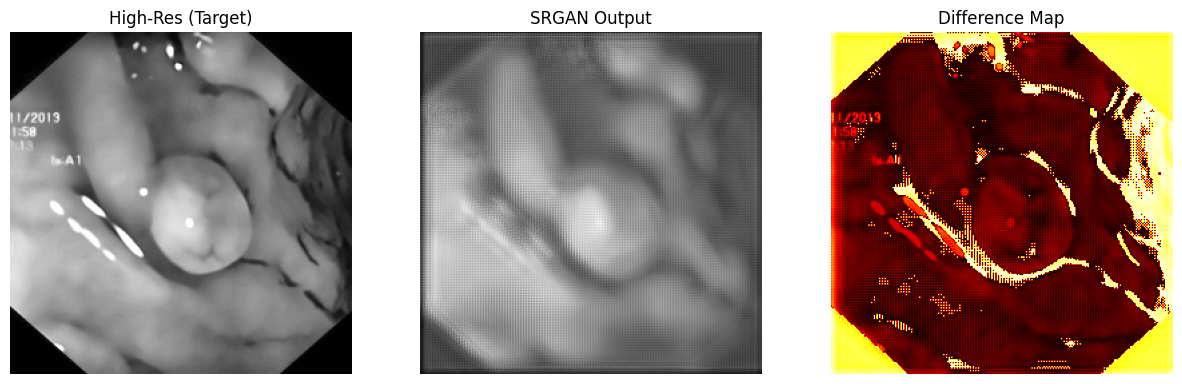

SRGAN - PSNR: 17.44 dB, SSIM: 0.4592


In [35]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

# Revised SuperResDataset: Low-res input remains at 128x128
class SuperResDataset(torch.utils.data.Dataset):
    """
    Dataset for Super Resolution:
    - Loads high-res images (target) from a folder.
    - Generates low-res inputs by downscaling without upscaling back.
    """
    def __init__(self, image_dir, scale_factor=2):
        self.image_dir = image_dir
        self.image_files = [os.path.join(image_dir, f) for f in os.listdir(image_dir) 
                            if f.lower().endswith(('.jpg', '.png', '.jpeg')) and 'enhanced' in f]
        self.scale_factor = scale_factor
        
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        # Load high-res image in grayscale and resize to 256x256
        hr_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        hr_img = cv2.resize(hr_img, (256, 256))
        hr_img = hr_img.astype(np.float32) / 255.0
        
        # Create low-resolution input: downscale using bicubic interpolation only (keep at 128x128)
        lr_size = (256 // self.scale_factor, 256 // self.scale_factor)  # (128, 128)
        lr_img = cv2.resize(hr_img, lr_size, interpolation=cv2.INTER_CUBIC)
        
        # Convert to torch tensors and add channel dimension
        hr_tensor = torch.tensor(hr_img, dtype=torch.float32).unsqueeze(0)  # 1x256x256
        lr_tensor = torch.tensor(lr_img, dtype=torch.float32).unsqueeze(0)  # 1x128x128
        
        return lr_tensor, hr_tensor

# Instantiate dataset and dataloader
dataset_dir = "/kaggle/working/processed_data"  # Directory with preprocessed 'enhanced' images
srgan_dataset = SuperResDataset(dataset_dir, scale_factor=2)
srgan_loader = DataLoader(srgan_dataset, batch_size=4, shuffle=True)

# -----------------------------
# SRGAN Generator (scale factor = 2)
# -----------------------------
class SRGAN_Generator(nn.Module):
    def __init__(self):
        super(SRGAN_Generator, self).__init__()
        # Initial convolution block
        self.conv1 = nn.Conv2d(1, 64, kernel_size=9, padding=4)
        self.relu = nn.ReLU(inplace=True)
        # Residual blocks (simplified: 4 blocks for demonstration)
        self.res_blocks = nn.Sequential(
            *[self._make_res_block(64) for _ in range(4)]
        )
        # Upsampling layer: upsample from 128x128 to 256x256
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2),
            nn.ReLU(inplace=True)
        )
        # Final output layer to produce a 256x256 image
        self.conv2 = nn.Conv2d(64, 1, kernel_size=9, padding=4)
    
    def _make_res_block(self, channels):
        block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels)
        )
        return block
    
    def forward(self, x):
        # x is expected to be low-resolution (128x128)
        x = self.relu(self.conv1(x))
        res = self.res_blocks(x)
        x = x + res  # Residual connection
        x = self.upsample(x)  # Upsample to 256x256
        x = self.conv2(x)
        return x

# -----------------------------
# SRGAN Discriminator
# -----------------------------
class SRGAN_Discriminator(nn.Module):
    def __init__(self):
        super(SRGAN_Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1), 
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm2d(64), 
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(128), 
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm2d(128), 
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(256), 
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm2d(256), 
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Flatten(),
            nn.Linear(256 * 32 * 32, 1024),  # 256x32x32 = 262144 features expected for 256x256 images
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 1)
        )
    
    def forward(self, x):
        return self.net(x)

# Instantiate Generator and Discriminator
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = SRGAN_Generator().to(device)
discriminator = SRGAN_Discriminator().to(device)

# Loss functions
criterion_content = nn.MSELoss()       # Content loss (pixel-wise MSE)
criterion_adversarial = nn.BCEWithLogitsLoss()  # Adversarial loss

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=1e-4)
optimizer_D = optim.Adam(discriminator.parameters(), lr=1e-4)

# Labels for adversarial training
real_label = 1.0
fake_label = 0.0

num_epochs_gan = 20  # Adjust as needed

for epoch in range(num_epochs_gan):
    generator.train()
    discriminator.train()
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    
    for lr_imgs, hr_imgs in srgan_loader:
        # lr_imgs: shape (batch, 1, 128, 128), hr_imgs: shape (batch, 1, 256, 256)
        lr_imgs = lr_imgs.to(device)
        hr_imgs = hr_imgs.to(device)
        
        # =======================
        # Train Discriminator
        # =======================
        optimizer_D.zero_grad()
        
        # Real images: label 1
        output_real = discriminator(hr_imgs)
        labels_real = torch.full_like(output_real, real_label, device=device)
        loss_d_real = criterion_adversarial(output_real, labels_real)
        
        # Fake images: generator output, label 0
        fake_hr = generator(lr_imgs)
        output_fake = discriminator(fake_hr.detach())
        labels_fake = torch.full_like(output_fake, fake_label, device=device)
        loss_d_fake = criterion_adversarial(output_fake, labels_fake)
        
        # Combined discriminator loss
        loss_D = (loss_d_real + loss_d_fake) * 0.5
        loss_D.backward()
        optimizer_D.step()
        
        # =======================
        # Train Generator
        # =======================
        optimizer_G.zero_grad()
        
        # Content loss (MSE) ensures generated image is close to high-res target
        loss_content = criterion_content(fake_hr, hr_imgs)
        
        # Adversarial loss: generator wants discriminator to classify fake as real
        output_fake_for_G = discriminator(fake_hr)
        labels_for_G = torch.full_like(output_fake_for_G, real_label, device=device)
        loss_adv = criterion_adversarial(output_fake_for_G, labels_for_G)
        
        # Total generator loss: weight adversarial loss appropriately (e.g., 1e-3 factor)
        loss_G = loss_content + 1e-3 * loss_adv
        loss_G.backward()
        optimizer_G.step()
        
        epoch_g_loss += loss_G.item() * lr_imgs.size(0)
        epoch_d_loss += loss_D.item() * lr_imgs.size(0)
    
    avg_loss_G = epoch_g_loss / len(srgan_dataset)
    avg_loss_D = epoch_d_loss / len(srgan_dataset)
    print(f"SRGAN Epoch [{epoch+1}/{num_epochs_gan}], G Loss: {avg_loss_G:.4f}, D Loss: {avg_loss_D:.4f}")

# Save SRGAN models
torch.save(generator.state_dict(), "srgan_generator.pth")
torch.save(discriminator.state_dict(), "srgan_discriminator.pth")
print("SRGAN models saved successfully!")

# -----------------------------
# Evaluation Function for SRGAN
# -----------------------------
def evaluate_srgan(generator, image_path):
    generator.eval()
    # Load high-res target image
    hr_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    hr_img = cv2.resize(hr_img, (256, 256))
    hr_img_norm = hr_img.astype(np.float32) / 255.0
    
    # Create low-res input (simulate low-res via downscaling only, keep at 128x128)
    lr_size = (256 // 2, 256 // 2)  # (128, 128)
    lr_img = cv2.resize(hr_img_norm, lr_size, interpolation=cv2.INTER_CUBIC)
    # Do not upscale here—generator will upscale it
    lr_tensor = torch.tensor(lr_img, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    
    with torch.no_grad():
        fake_hr = generator(lr_tensor)
    fake_hr_img = fake_hr.squeeze().cpu().numpy() * 255.0
    fake_hr_img = np.clip(fake_hr_img, 0, 255).astype(np.uint8)
    
    # Compute PSNR and SSIM
    psnr_val = psnr(hr_img, fake_hr_img, data_range=255)
    ssim_val = ssim(hr_img, fake_hr_img, data_range=255)
    
    # Visualize the results
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(hr_img, cmap='gray'); axs[0].set_title("High-Res (Target)"); axs[0].axis('off')
    axs[1].imshow(fake_hr_img, cmap='gray'); axs[1].set_title("SRGAN Output"); axs[1].axis('off')
    diff = np.abs(hr_img - fake_hr_img)
    axs[2].imshow(diff, cmap='hot'); axs[2].set_title("Difference Map"); axs[2].axis('off')
    plt.show()
    
    return psnr_val, ssim_val

# Example evaluation for SRGAN
test_img_path = "/kaggle/input/preprocessed2/PreProcessed1/processed_image_10.jpg"  # Replace with your test image path
psnr_srgan, ssim_srgan = evaluate_srgan(generator, test_img_path)
print(f"SRGAN - PSNR: {psnr_srgan:.2f} dB, SSIM: {ssim_srgan:.4f}")

Epoch 1, Batch 0, Combined Loss: 0.2696
   loss_final: 0.1540, loss_unet: 0.1706, loss_perc: 3.2469, loss_ssim: 0.9649
   UNet out range: -0.027236128225922585 -0.02065229043364525
   SR out range: 0.010326145216822624 0.013618064112961292
   Final out range: 0.0 0.0
[Epoch 1/3000] Avg Combined Loss: 0.2704
Epoch 2, Batch 0, Combined Loss: 0.2512
   loss_final: 0.1404, loss_unet: 0.1559, loss_perc: 3.4939, loss_ssim: 0.9322
   UNet out range: -0.0271048154681921 -0.020467624068260193
   SR out range: 0.010233812034130096 0.01355240773409605
   Final out range: 0.0 0.0
[Epoch 2/3000] Avg Combined Loss: 0.2704
Epoch 3, Batch 0, Combined Loss: 0.2653
   loss_final: 0.1505, loss_unet: 0.1665, loss_perc: 3.6637, loss_ssim: 0.9309
   UNet out range: -0.026965565979480743 -0.020285027101635933
   SR out range: 0.010142513550817966 0.013482782989740372
   Final out range: 0.0 0.0
[Epoch 3/3000] Avg Combined Loss: 0.2704
Epoch 4, Batch 0, Combined Loss: 0.2511
   loss_final: 0.1404, loss_unet: 

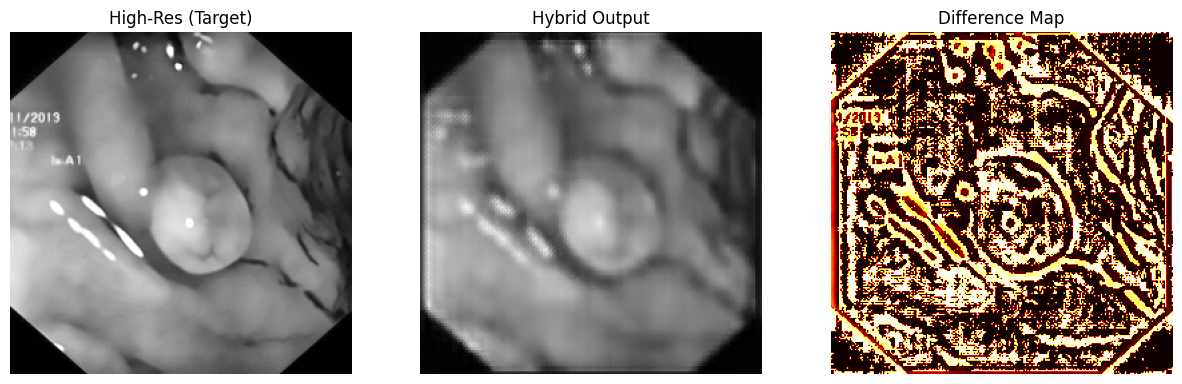

Hybrid Model - PSNR: 25.10, SSIM: 0.8228


In [47]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from torchvision.models import vgg16
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

# -----------------------------
# 1) SSIM Loss
# -----------------------------
def ssim_loss(pred, target, window_size=11, C1=0.01**2, C2=0.03**2):
    """
    pred, target: [B, 1, H, W], in [0,1].
    Returns (1 - SSIM) averaged over the batch.
    """
    pred = pred.float()
    target = target.float()

    mu_pred = nn.functional.avg_pool2d(pred, window_size, 1, window_size//2)
    mu_target = nn.functional.avg_pool2d(target, window_size, 1, window_size//2)

    mu_pred_sq = mu_pred * mu_pred
    mu_target_sq = mu_target * mu_target
    mu_pred_target = mu_pred * mu_target

    sigma_pred_sq = nn.functional.avg_pool2d(pred * pred, window_size, 1, window_size//2) - mu_pred_sq
    sigma_target_sq = nn.functional.avg_pool2d(target * target, window_size, 1, window_size//2) - mu_target_sq
    sigma_pred_target = nn.functional.avg_pool2d(pred * target, window_size, 1, window_size//2) - mu_pred_target

    ssim_map = ((2 * mu_pred_target + C1) * (2 * sigma_pred_target + C2)) / \
               ((mu_pred_sq + mu_target_sq + C1) * (sigma_pred_sq + sigma_target_sq + C2))

    ssim_val = ssim_map.mean()  
    return 1.0 - ssim_val       # 1 - SSIM

# -----------------------------
# 2) Perceptual Loss
# -----------------------------
class PerceptualLoss(nn.Module):
    def __init__(self):
        super(PerceptualLoss, self).__init__()
        vgg = vgg16(pretrained=True).features[:8].eval()  # up to relu2_2
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg

    def forward(self, pred, target):
        # replicate to 3 channels for VGG
        pred_3c = pred.repeat(1, 3, 1, 1)
        target_3c = target.repeat(1, 3, 1, 1)
        pred_feats = self.vgg(pred_3c)
        target_feats = self.vgg(target_3c)
        return nn.functional.mse_loss(pred_feats, target_feats)

# -----------------------------
# 3) UNet (No Sigmoid in Final)
# -----------------------------
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(True),
            nn.MaxPool2d(2)
        )
        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1), nn.ReLU(True)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 2, stride=2), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 2, stride=2), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 2, stride=2), nn.ReLU(True)
        )
        # Final (no sigmoid)
        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        enc = self.encoder(x)
        bottleneck = self.bottleneck(enc)
        dec = self.decoder(bottleneck)
        out = self.final(dec)  # can be <0 or >1
        return out

# -----------------------------
# 4) SRCNN (No Sigmoid)
# -----------------------------
class SRCNN(nn.Module):
    def __init__(self):
        super(SRCNN, self).__init__()
        self.upsample = nn.ConvTranspose2d(1, 1, kernel_size=2, stride=2)  # 128->256
        self.layer1 = nn.Conv2d(1, 64, kernel_size=9, padding=4)
        self.relu = nn.ReLU(True)
        self.layer2 = nn.Conv2d(64, 32, kernel_size=5, padding=2)
        self.layer3 = nn.Conv2d(32, 1, kernel_size=5, padding=2)
        # No final activation here

    def forward(self, x):
        x = self.upsample(x)
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)  # can be <0 or >1
        return x

# -----------------------------
# 5) Hybrid: UNet -> downscale -> SRCNN + skip
# -----------------------------
class HybridEnhancement(nn.Module):
    def __init__(self, unet, srcnn):
        super(HybridEnhancement, self).__init__()
        self.unet = unet
        self.srcnn = srcnn
        self.downscale = nn.AvgPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        unet_out = self.unet(x)                # shape [B,1,256,256]
        down = self.downscale(unet_out)        # shape [B,1,128,128]
        sr_out = self.srcnn(down)             # shape [B,1,256,256]
        
        # Skip connection: combine UNet output + SR output
        final_out = 0.5 * unet_out + 0.5 * sr_out
        
        # Clamp final to [0,1] to avoid black or white saturations
        final_out = torch.clamp(final_out, 0.0, 1.0)
        return final_out, unet_out

# -----------------------------
# 6) Dataset
# -----------------------------
class HighResDataset(Dataset):
    def __init__(self, image_dir):
        self.image_dir = image_dir
        self.image_files = [
            os.path.join(image_dir, f) for f in os.listdir(image_dir)
            if f.lower().endswith(('.jpg', '.png', '.jpeg')) and 'enhanced' in f
        ]
    def __len__(self):
        return len(self.image_files)
    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (256, 256))
        img = img.astype(np.float32) / 255.0
        tensor = torch.tensor(img).unsqueeze(0)  # [1,256,256]
        return tensor, tensor

# -----------------------------
# 7) Training Function
# -----------------------------
def train_hybrid(
    dataset_dir,
    epochs=1000,
    alpha=1.0,    # weight for final MSE
    beta=0.3,     # weight for UNet MSE
    gamma=0.005,  # weight for perceptual loss
    delta=0.05,   # weight for SSIM-based loss
    lr=1e-5,
    max_grad_norm=1.0
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Model
    unet = UNet().to(device)
    srcnn = SRCNN().to(device)
    model = HybridEnhancement(unet, srcnn).to(device)

    # Data
    dataset = HighResDataset(dataset_dir)
    dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

    # Losses
    mse_loss = nn.MSELoss()
    perc_loss_fn = PerceptualLoss().to(device)

    # Optimizer
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for i, (inp, tgt) in enumerate(dataloader):
            inp, tgt = inp.to(device), tgt.to(device)

            optimizer.zero_grad()
            final_out, unet_out = model(inp)

            # 1) MSE on final output
            loss_final = mse_loss(final_out, tgt)
            # 2) Auxiliary MSE on UNet output
            loss_unet = mse_loss(unet_out, tgt)
            # 3) Perceptual Loss on final output
            loss_perc = perc_loss_fn(final_out, tgt)
            # 4) SSIM-based loss
            loss_ssim = ssim_loss(final_out, tgt)  # in [0,1]

            # Weighted sum
            loss = alpha*loss_final + beta*loss_unet + gamma*loss_perc + delta*loss_ssim
            loss.backward()

            nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

            running_loss += loss.item() * inp.size(0)

            # Debug prints for first batch
            if i == 0:
                print(f"Epoch {epoch+1}, Batch {i}, Combined Loss: {loss.item():.4f}")
                print(f"   loss_final: {loss_final.item():.4f}, loss_unet: {loss_unet.item():.4f}, "
                      f"loss_perc: {loss_perc.item():.4f}, loss_ssim: {loss_ssim.item():.4f}")
                print("   UNet out range:", unet_out.min().item(), unet_out.max().item())
                print("   SR out range:", (0.5 * final_out - 0.5 * unet_out).min().item(), 
                      (0.5 * final_out - 0.5 * unet_out).max().item())
                print("   Final out range:", final_out.min().item(), final_out.max().item())

        epoch_loss = running_loss / len(dataset)
        print(f"[Epoch {epoch+1}/{epochs}] Avg Combined Loss: {epoch_loss:.4f}")

    # Save model
    torch.save(model.state_dict(), "hybrid_enhancement_model.pth")
    print("Hybrid model saved successfully!")
    return model

# -----------------------------
# 8) Evaluation
# -----------------------------
def evaluate_hybrid(model, image_path):
    model.eval()
    device = next(model.parameters()).device

    hr_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    hr_img = cv2.resize(hr_img, (256, 256))
    hr_img_norm = hr_img.astype(np.float32) / 255.0
    inp_tensor = torch.tensor(hr_img_norm).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        final_out, _ = model(inp_tensor)
    out_img = final_out.squeeze().cpu().numpy() * 255.0
    out_img = np.clip(out_img, 0, 255).astype(np.uint8)

    # Metrics
    psnr_val = psnr(hr_img, out_img, data_range=255)
    ssim_val = ssim(hr_img, out_img, data_range=255)

    # Visualization
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(hr_img, cmap='gray')
    axs[0].set_title("High-Res (Target)")
    axs[0].axis('off')

    axs[1].imshow(out_img, cmap='gray')
    axs[1].set_title("Hybrid Output")
    axs[1].axis('off')

    diff = np.abs(hr_img - out_img)
    axs[2].imshow(diff, cmap='hot')
    axs[2].set_title("Difference Map")
    axs[2].axis('off')
    plt.show()

    print(f"Hybrid Model - PSNR: {psnr_val:.2f}, SSIM: {ssim_val:.4f}")
    return psnr_val, ssim_val

# -----------------------------
# Example Main
# -----------------------------
if __name__ == "__main__":
    dataset_dir = "/kaggle/working/processed_data"
    test_img_path = "/kaggle/input/preprocessed2/PreProcessed1/processed_image_10.jpg"

    model = train_hybrid(
        dataset_dir=dataset_dir,
        epochs=3000,
        alpha=1.0,
        beta=0.3,
        gamma=0.005,
        delta=0.05,
        lr=1e-5
    )

    evaluate_hybrid(model, test_img_path)
